# SAE Jacobian Projection 
This notebook shows one concrete point-level projection pipeline:
1. estimate a local score-increasing direction on the manifold,
2. map that direction to ambient embedding space,
3. project it into SAE latent space using Jacobian-vector product and finite differences.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
import plotly.graph_objects as go
from sklearn.linear_model import Lasso

# Make src importable
REPO_ROOT = Path.cwd().resolve()
SRC_DIR = (REPO_ROOT / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Naive imports (no importlib reload indirection)
from SAE.SAE_training.utils.data import build_artifacts, extract_concat_matrix
from SAE.SAE_training.model import SAEConfig, SparseAutoencoder, estimate_latent_direction_scores
from SAE.manifold.core import TangentSpace, estimate_point_score_direction, project_to_tangent

sns.set_theme(style="whitegrid")
print("Repo root:", REPO_ROOT)

Repo root: /home/guoyu/SLformer_interpretation


## Mathematical Setup
We work in a fixed cancer context and denote normalized embeddings by $x \in \mathbb{R}^{d}$ with $d=1024$.
The SAE encoder is a map $f_\theta: \mathbb{R}^{d} \to \mathbb{R}^{m}$, producing latent code $z=f_\theta(x)$.
Our goal is to explain one target point $x_0$ by constructing a local score-increasing direction in embedding space, then projecting that direction into latent space.
Pipeline summary:
$$
x_0 \xrightarrow{\text{local manifold geometry}} \hat v \xrightarrow{\text{encoder differential}} \dot z
$$
where $\hat v$ is the local unit ambient direction and $\dot z$ is latent directional sensitivity.

In [2]:
# --- Load configs + SAE checkpoint ---
CONFIG_PATH = (REPO_ROOT / "src" / "SAE" / "SAE_training" / "config" / "train_config.yaml").resolve()
MANIFOLD_CONFIG_PATH = (REPO_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml").resolve()

cfg = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
manifold_cfg = yaml.safe_load(MANIFOLD_CONFIG_PATH.read_text(encoding="utf-8"))
proj_cfg = manifold_cfg["projection"]

paths_cfg = cfg["paths"]
scope_cfg = cfg["scope"]

model_dict = dict(cfg["model"])
model_cfg = SAEConfig(**model_dict)

CANCER = str(scope_cfg["cancer"])
SCORE_COL = str(scope_cfg["score_col"])
SEED = int(scope_cfg["seed"])

embeddings_pkl = Path(paths_cfg["embeddings_pkl"]).expanduser().resolve()
prediction_csvs = [Path(p).expanduser().resolve() for p in paths_cfg["prediction_csvs"]]
output_base_dir = Path(paths_cfg["output_base_dir"]).expanduser().resolve()
slformer_output_subdir = str(paths_cfg["slformer_output_subdir"])

run_name = f"hidden{model_cfg.d_hidden}_gate{model_cfg.gate_weight}_orth{model_cfg.orth_weight}_k{model_cfg.topk}"
run_dir = output_base_dir / slformer_output_subdir / CANCER / run_name

mu = np.load(run_dir / "norm" / "mu.npy")
sigma = np.load(run_dir / "norm" / "sigma.npy")

ckpt = torch.load(run_dir / "final.pt", map_location="cpu")
sae_cfg_loaded = SAEConfig(**ckpt["sae_cfg"])
model = SparseAutoencoder(sae_cfg_loaded)
model.load_state_dict(ckpt["state_dict"])
model.eval()

print("Run dir:", run_dir)
print("Loaded SAE:", sae_cfg_loaded)
print("Projection config:", proj_cfg)

Run dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64
Loaded SAE: SAEConfig(d_in=1024, d_hidden=4096, activation='jumprelu', orth_weight=1, decoder_unit_norm=True, topk=64, gate_weight=0.5, jump_threshold=0.0)
Projection config: {'metric': 'cosine', 'tangent_dim': 24, 'ridge_alpha': 0.001, 'default_neighbors': 25, 'neighbor_min': 35, 'neighbor_max': 400, 'neighbor_step': 10, 'fd_eps': 0.001, 'topk_features': 20, 'decoder_lasso_alpha': 0.0005, 'decoder_lasso_grid_size': 10, 'arrow_scale': 0.7}


In [3]:
# --- Build within-cancer matrix and normalize ---
artifacts = build_artifacts(embeddings_pkl=embeddings_pkl, prediction_csvs=prediction_csvs)
X, y, meta = extract_concat_matrix(artifacts, cancer=CANCER, seed=SEED, use_score_col=SCORE_COL)
Xn = ((X - mu) / (sigma + 1e-8)).astype(np.float32)

print("Xn:", Xn.shape, "y:", y.shape)
meta.head(3)

Xn: (58672, 1024) y: (58672,)


,primary_gene,partner_gene,cancer,score,fold
0,AKT1,BCL2,KIRC,0.000425,0
1,PTEN,RUNX1,KIRC,0.001516,0
2,HDAC6,SMARCA4,KIRC,0.005020,0


## Normalization and Coordinates
Training-space normalization is coordinate-wise:
$$
\mu_j = \frac{1}{N_{tr}}\sum_{i=1}^{N_{tr}}X_{ij}, \qquad
\sigma_j = \sqrt{\frac{1}{N_{tr}}\sum_{i=1}^{N_{tr}}(X_{ij}-\mu_j)^2}+\varepsilon,
$$
$$
\tilde X_{ij}=\frac{X_{ij}-\mu_j}{\sigma_j}.
$$
All subsequent geometric quantities are computed in this normalized space so that manifold and SAE projections are consistent with training coordinates.

In [4]:
# --- Pick one concrete point to explain ---
target_idx = int(np.argmax(y))  # example: highest SL score sample
x0 = Xn[target_idx]
print("target_idx:", target_idx)
print("score:", float(y[target_idx]))
print("pair:", meta.loc[target_idx, "primary_gene"], "-", meta.loc[target_idx, "partner_gene"])

target_idx: 43668
score: 0.9995158910751343
pair: BRCA1 - BRD9


## Local Manifold Direction at the Target Point
Given target point $x_0$, we collect neighbors $\mathcal{N}(x_0)$ and fit local PCA on centered neighbors to obtain basis $B\in\mathbb{R}^{d\times k}$ with $B^\top B=I_k$.
Local tangent coordinates are
$$
u(x)=B^\top(x-\mu),
$$
where $\mu$ is the neighborhood mean.
We fit a local linear score model in tangent coordinates:
$$
s(x) \approx \beta_0 + g^\top u(x) = \beta_0 + g^\top B^\top(x-\mu).
$$
This gives a tangent gradient $g\in\mathbb{R}^k$ and ambient gradient
$$
\mathrm{grad\_ambient}=v:=Bg\in\mathbb{R}^d, \qquad \hat v = \frac{v}{\lVert v \rVert_2}.
$$
So `grad_ambient` is the local score-increasing direction lifted from tangent coordinates back to embedding coordinates.

We decompose the centered target offset
$$
\Delta x := x_0-\mu
$$
into tangent and normal components using the projection operator $P_T=BB^\top$:
$$
X_{\mathrm{tangent}} = P_T\Delta x = BB^\top\Delta x,
$$
$$
X_{\mathrm{normal}} = (I-P_T)\Delta x = (I-BB^\top)\Delta x.
$$
In code these correspond to `x_tan` and `x_norm`.
Their norms measure how much of the target displacement lies on the estimated local manifold versus off-manifold.

In [5]:
# --- Score field -> local manifold direction at x0 ---
res = estimate_point_score_direction(
    Xn,
    y.astype(np.float32),
    point_index=target_idx,
    n_neighbors=int(proj_cfg["default_neighbors"]),
    metric=str(proj_cfg["metric"]),
    tangent_dim=int(proj_cfg["tangent_dim"]),
    ridge_alpha=float(proj_cfg["ridge_alpha"]),
)

v = res["grad_ambient_unit"]  # ambient unit direction in x-space

tangent = TangentSpace(basis=res["basis"], mean=res["mu"])
x0_centered = x0 - tangent.mean
x_tan, x_norm = project_to_tangent(x0_centered, tangent)

print("neighbor_count:", int(res["neighbor_indices"].shape[0]))
print("||grad_ambient||:", float(np.linalg.norm(res["grad_ambient"])))
print("||x_tangent_component||:", float(np.linalg.norm(x_tan)))
print("||x_normal_component||:", float(np.linalg.norm(x_norm)))

neighbor_count: 25
||grad_ambient||: 0.03490515425801277
||x_tangent_component||: 14.199217796325684
||x_normal_component||: 18.117538452148438


## Neighbor Sweep: Stability of Local Direction Geometry
We track three norms as neighborhood size varies:
- $\|\mathrm{grad\_ambient}\|_2 = \|Bg\|_2$ from local tangent regression.
- $\|X_{\mathrm{tangent}}\|_2 = \|BB^\top(x_0-\mu)\|_2$.
- $\|X_{\mathrm{normal}}\|_2 = \|(I-BB^\top)(x_0-\mu)\|_2$.
This reveals how local geometry changes with neighborhood scale.

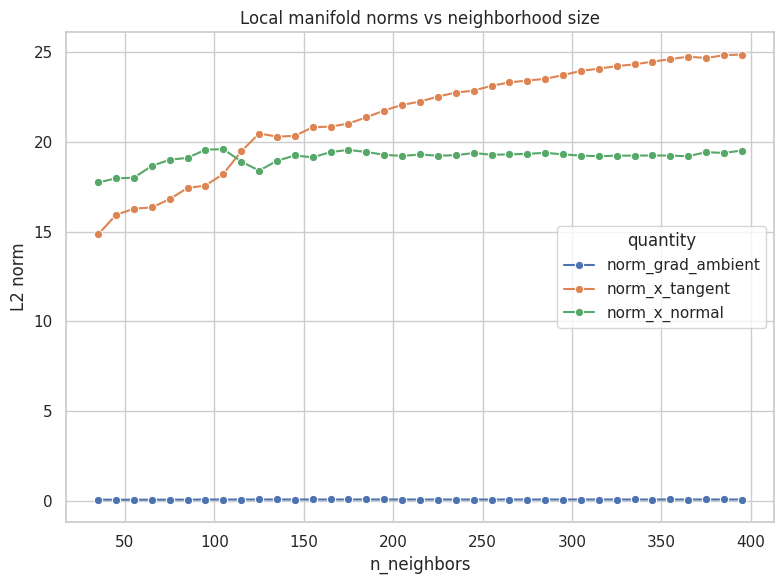

In [6]:
# --- Norm sweep over neighborhood size ---
n_min = int(proj_cfg["neighbor_min"])
n_max = int(proj_cfg["neighbor_max"])
n_step = int(proj_cfg["neighbor_step"])
neighbor_grid = np.arange(n_min, n_max + 1, n_step, dtype=int)

rows = []
base_tangent_dim = int(proj_cfg["tangent_dim"])

for n_nb in neighbor_grid:
    res_n = estimate_point_score_direction(
        Xn,
        y.astype(np.float32),
        point_index=target_idx,
        n_neighbors=int(n_nb),
        metric=str(proj_cfg["metric"]),
        tangent_dim=base_tangent_dim,
        ridge_alpha=float(proj_cfg["ridge_alpha"]),
    )
    tangent_n = TangentSpace(basis=res_n["basis"], mean=res_n["mu"])
    dx = x0 - tangent_n.mean
    x_tan_n, x_norm_n = project_to_tangent(dx, tangent_n)
    rows.append(
        {
            "neighbors": int(n_nb),
            "tangent_dim_used": int(base_tangent_dim),
            "norm_grad_ambient": float(np.linalg.norm(res_n["grad_ambient"])),
            "norm_x_tangent": float(np.linalg.norm(x_tan_n)),
            "norm_x_normal": float(np.linalg.norm(x_norm_n)),
        }
    )

df_norms = pd.DataFrame(rows)
df_norms_long = df_norms.melt(
    id_vars=["neighbors", "tangent_dim_used"],
    value_vars=["norm_grad_ambient", "norm_x_tangent", "norm_x_normal"],
    var_name="quantity",
    value_name="value",
)

plt.figure(figsize=(8, 6))
sns.lineplot(data=df_norms_long, x="neighbors", y="value", hue="quantity", marker="o")
plt.title("Local manifold norms vs neighborhood size")
plt.xlabel("n_neighbors")
plt.ylabel("L2 norm")
plt.tight_layout()
plt.show()


In [7]:
# --- Ambient direction -> SAE latent sensitivity (JVP only) ---
x0_t = torch.from_numpy(x0).unsqueeze(0)
v_t = torch.from_numpy(v).unsqueeze(0)

scores = estimate_latent_direction_scores(
    model,
    x0_t,
    v_t,
)
z0 = scores["z0"].detach().cpu().numpy()[0]
jvp = scores["jvp"].detach().cpu().numpy()[0]

topk = int(proj_cfg["topk_features"])
idx = np.argsort(np.abs(jvp))[::-1][:topk]
df_top = pd.DataFrame(
    {
        "feature": idx,
        "z0": z0[idx],
        "jvp": jvp[idx],
        "abs_jvp": np.abs(jvp[idx]),
    }
).sort_values("abs_jvp", ascending=False).reset_index(drop=True)
df_top

,feature,z0,jvp,abs_jvp
0,2219,3.987525,0.117848,0.117848
1,3090,2.442991,0.104034,0.104034
2,1045,2.028841,-0.103703,0.103703
3,315,8.861159,0.086864,0.086864
4,3232,2.960958,-0.086578,0.086578
5,128,7.353415,0.085577,0.085577
6,261,3.972402,0.084057,0.084057
7,2186,4.364411,0.070946,0.070946
8,1212,3.525895,0.068970,0.068970
9,3261,4.470026,-0.067218,0.067218


## Decoder Argmin Projection $\arg\min_c \|W_d c-\hat v\|_2^2 + \lambda\|c\|_1$
We solve a sparse reconstruction of the local ambient direction $\hat v$ in the decoder dictionary.
Numerically we use Lasso with no intercept to estimate sparse coefficients $c^*$.
Then we compare $\hat v$ and $W_d c^*$ by cosine similarity and relative error, and visualize directional alignment with arrows in a 2D projected subspace.

Selected alpha: 9.76563e-07
Non-zero coeffs: 1020/4096
cos(v, Wd c*): 0.9999
relative reconstruction error: 0.0219


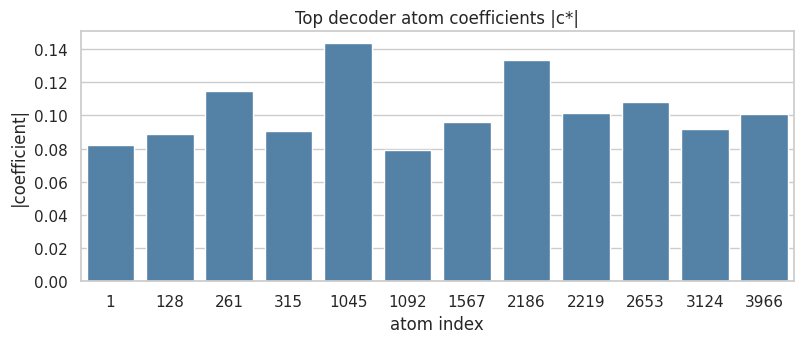

In [8]:
# --- Sparse decoder projection of ambient direction (argmin problem) ---
W_d = model.decoder.weight.detach().cpu().numpy().astype(np.float32)  # (d_in, d_hidden)
v_unit = v / (np.linalg.norm(v) + 1e-12)

# Column-normalize dictionary for better numerical conditioning
col_norm = np.linalg.norm(W_d, axis=0) + 1e-12
Wn = W_d / col_norm

base_alpha = float(proj_cfg["decoder_lasso_alpha"])
alpha_grid = [base_alpha * (0.5 ** i) for i in range(10)]

best = None
for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=50000)
    lasso.fit(Wn, v_unit)
    b = lasso.coef_.astype(np.float32)
    c = b / col_norm

    v_recon = W_d @ c
    v_recon_unit = v_recon / (np.linalg.norm(v_recon) + 1e-12)
    nnz = int(np.count_nonzero(np.abs(c) > 1e-8))
    cosine = float(np.dot(v_unit, v_recon_unit))
    rel_err = float(np.linalg.norm(v_unit - v_recon) / (np.linalg.norm(v_unit) + 1e-12))

    cand = {
        "alpha": float(alpha),
        "c_star": c,
        "nnz": nnz,
        "cosine": cosine,
        "rel_err": rel_err,
        "v_recon": v_recon,
        "v_recon_unit": v_recon_unit,
    }

    if best is None or (cand["nnz"] > 0 and cand["cosine"] > best["cosine"]):
        best = cand

c_star = best["c_star"]
v_recon = best["v_recon"]
v_recon_unit = best["v_recon_unit"]

print(f"Selected alpha: {best['alpha']:.6g}")
print(f"Non-zero coeffs: {best['nnz']}/{c_star.shape[0]}")
print(f"cos(v, Wd c*): {best['cosine']:.4f}")
print(f"relative reconstruction error: {best['rel_err']:.4f}")

# Top contributing atoms
n_show = 12
top_atoms = np.argsort(np.abs(c_star))[::-1][:n_show]
df_atoms = pd.DataFrame(
    {
        "atom": top_atoms,
        "coef": c_star[top_atoms],
        "abs_coef": np.abs(c_star[top_atoms]),
    }
).sort_values("abs_coef", ascending=False)

# Panel A: coefficient magnitudes
plt.figure(figsize=(8.2, 3.6))
sns.barplot(data=df_atoms, x="atom", y="abs_coef", color="steelblue")
plt.title("Top decoder atom coefficients |c*|")
plt.xlabel("atom index")
plt.ylabel("|coefficient|")
plt.xticks()
plt.tight_layout()
plt.show()

## Projection into SAE Latent Space (JVP)
Let the (sparse) encoder be $z=f_\theta(x)\in\mathbb{R}^m$ and fix a target point $x_0\in\mathbb{R}^d$.
We obtain a *unit* ambient direction $\hat v\in\mathbb{R}^d$ from local manifold regression (previous section).

**Directional derivative in latent space.**
The first-order change in the latent code along direction $\hat v$ is the Jacobian–vector product (JVP):
$$
\dot z \;:=\; \left.\frac{d}{d\epsilon} f_\theta(x_0 + \epsilon \hat v)\right|_{\epsilon=0} 
\;=\; J_f(x_0)\,\hat v,
$$
where $J_f(x_0)\in\mathbb{R}^{m\times d}$ is the encoder Jacobian at $x_0$.


In [9]:
# --- JVP summary ---
print("Top-5 features by |jvp|:")
print(df_top.head(5).to_string(index=False))

print("||jvp||_2:", float(np.linalg.norm(jvp)))
print("mean |jvp|:", float(np.mean(np.abs(jvp))))

Top-5 features by |jvp|:
 feature       z0       jvp  abs_jvp
    2219 3.987525  0.117848 0.117848
    3090 2.442991  0.104034 0.104034
    1045 2.028841 -0.103703 0.103703
     315 8.861159  0.086864 0.086864
    3232 2.960958 -0.086578 0.086578
||jvp||_2: 0.3741565942764282
mean |jvp|: 0.0005876885261386633


## Encoder vs. Decoder Alignment: Top Features Overlap
We now compare the **two views** of the score-increasing direction:
1. **Encoder view (JVP)**: which latent features increase along $\hat v$ (directional sensitivity).
2. **Decoder view (Lasso)**: which dictionary atoms reconstruct $\hat v$ (geometric composition).

These are dual perspectives: one is differential (how codes change), the other reconstructive (which atoms span the direction).
The overlap tells us which features are supported by *both* views—high confidence signals for interpretation.

=== Encoder vs. Decoder Alignment ===
Top-20 features by |jvp|: [np.int64(128), np.int64(245), np.int64(261), np.int64(315), np.int64(1045), np.int64(1092), np.int64(1212), np.int64(1413), np.int64(1582), np.int64(1775), np.int64(2186), np.int64(2219), np.int64(2535), np.int64(2550), np.int64(2875), np.int64(2963), np.int64(3090), np.int64(3232), np.int64(3261), np.int64(3911)]
Top-20 atoms by |c*|: [np.int64(1), np.int64(128), np.int64(261), np.int64(315), np.int64(1045), np.int64(1092), np.int64(1212), np.int64(1567), np.int64(2126), np.int64(2186), np.int64(2219), np.int64(2490), np.int64(2653), np.int64(3090), np.int64(3124), np.int64(3232), np.int64(3261), np.int64(3911), np.int64(3966), np.int64(4034)]
Overlap (in both top-20): [np.int64(128), np.int64(261), np.int64(315), np.int64(1045), np.int64(1092), np.int64(1212), np.int64(2186), np.int64(2219), np.int64(3090), np.int64(3232), np.int64(3261), np.int64(3911)]
Overlap percentage: 60.0% (12/20)


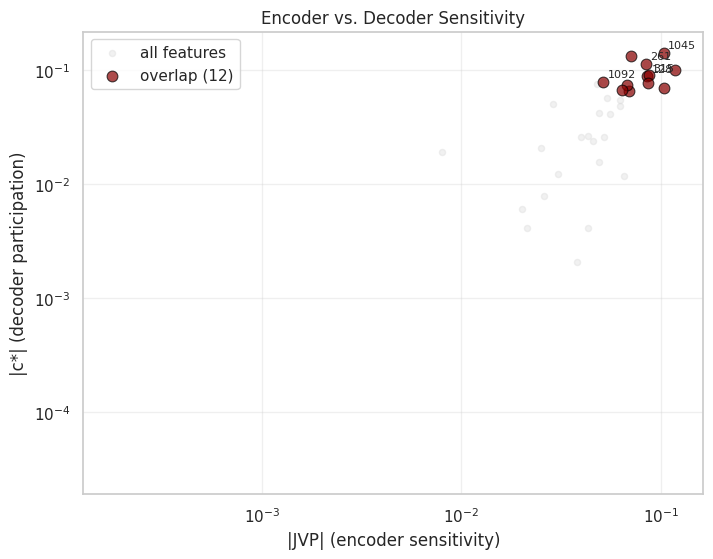

In [10]:
# --- Overlap analysis: top JVP features vs. top decoder atoms ---
topk_overlap = int(proj_cfg.get("topk_features", 16))

# Top features from JVP (encoder view)
jvp_top_idx = np.argsort(np.abs(jvp))[::-1][:topk_overlap]
jvp_top_set = set(jvp_top_idx)

# Top atoms from decoder projection (decoder view)
c_top_idx = np.argsort(np.abs(c_star))[::-1][:topk_overlap]
c_top_set = set(c_top_idx)

# Overlap metrics
overlap_idx = sorted(jvp_top_set & c_top_set)
overlap_count = len(overlap_idx)
overlap_pct = 100.0 * overlap_count / topk_overlap

# Summarize
print("=== Encoder vs. Decoder Alignment ===")
print(f"Top-{topk_overlap} features by |jvp|: {sorted(jvp_top_idx)}")
print(f"Top-{topk_overlap} atoms by |c*|: {sorted(c_top_idx)}")
print(f"Overlap (in both top-{topk_overlap}): {overlap_idx}")
print(f"Overlap percentage: {overlap_pct:.1f}% ({overlap_count}/{topk_overlap})")

# Create overlap visualization: scatter plot + bar alignment
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ax0 = axes

# Panel A: Scatter - JVP vs. |c*| for overlapping features
overlapping_jvp = []
overlapping_c = []
all_jvp = []
all_c = []

for j in range(len(jvp)):
    all_jvp.append(np.abs(jvp[j]))
    all_c.append(np.abs(c_star[j]))
    if j in overlap_idx:
        overlapping_jvp.append(np.abs(jvp[j]))
        overlapping_c.append(np.abs(c_star[j]))

ax0.scatter(all_jvp, all_c, s=20, alpha=0.3, label="all features", color="lightgray")
ax0.scatter(overlapping_jvp, overlapping_c, s=60, alpha=0.7, label=f"overlap ({overlap_count})", color="darkred", edgecolors="black", linewidth=0.8)

# Annotate overlap points
for j in overlap_idx[:5]:  # label top 5 overlaps
    ax0.annotate(str(j), (np.abs(jvp[j]), np.abs(c_star[j])), fontsize=8, xytext=(3, 3), textcoords="offset points")

ax0.set_xlabel("|JVP| (encoder sensitivity)")
ax0.set_ylabel("|c*| (decoder participation)")
ax0.set_title("Encoder vs. Decoder Sensitivity")
ax0.set_xscale("log")
ax0.set_yscale("log")
ax0.legend()
ax0.grid(True, alpha=0.3)